# Write-Up Figure Reproduction

This notebook regenerates every figure currently included in the LaTeX write-up. It uses matched random MLPs with width 256, depth 32, and He/ReLU weight scaling unless a cell says otherwise.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.special import erf, expit

FIG_DIR = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
WIDTH = 256
DEPTH = 32
WEIGHT_SEED = 0
HE_SCALE = np.sqrt(2.0 / WIDTH)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

rng_w = np.random.default_rng(WEIGHT_SEED)
WEIGHTS = [
    rng_w.normal(0.0, HE_SCALE, size=(WIDTH, WIDTH)).astype(np.float32)
    for _ in range(DEPTH)
]

def activation(name, z):
    if name == 'ReLU':
        return np.maximum(z, 0.0)
    if name == 'GELU':
        return 0.5 * z * (1.0 + erf(z / np.sqrt(2.0)))
    if name == 'SiLU':
        return z * expit(z)
    raise ValueError(name)

def activation_derivative(name, z):
    if name == 'ReLU':
        return (z > 0).astype(np.float32)
    if name == 'GELU':
        phi = np.exp(-0.5 * z * z) / np.sqrt(2.0 * np.pi)
        return 0.5 * (1.0 + erf(z / np.sqrt(2.0))) + z * phi
    if name == 'SiLU':
        s = expit(z)
        return s + z * s * (1.0 - s)
    raise ValueError(name)

def run_forward(name, n_samples, seed=42, keep_posts=False):
    rng = np.random.default_rng(seed)
    x = rng.standard_normal((n_samples, WIDTH)).astype(np.float32)
    min_pre, max_pre, firing_rates, posts = [], [], [], []
    for w in WEIGHTS:
        pre = x @ w
        min_pre.append(pre.min(axis=0))
        max_pre.append(pre.max(axis=0))
        firing_rates.append((pre > 0).mean(axis=0))
        x = activation(name, pre).astype(np.float32)
        if keep_posts:
            posts.append(x.copy())
    result = {
        'min_pre': np.array(min_pre),
        'max_pre': np.array(max_pre),
        'firing_rates': np.array(firing_rates),
    }
    if keep_posts:
        result['posts'] = posts
    return result

def relu_regimes(stats):
    off = stats['max_pre'] <= 0
    on = stats['min_pre'] > 0
    kink = ~(off | on)
    return off, kink, on

def smooth_regimes(name, n_samples=20_000, near_zero_eps=1e-3, near_linear_eps=1e-2):
    rng = np.random.default_rng(42)
    x = rng.standard_normal((n_samples, WIDTH)).astype(np.float32)
    low, mid, high = [], [], []
    for w in WEIGHTS:
        pre = x @ w
        deriv = activation_derivative(name, pre)
        act = activation(name, pre).astype(np.float32)
        low_mask = np.percentile(np.abs(act), 99, axis=0) < near_zero_eps
        high_mask = np.percentile(np.abs(deriv - 1.0), 99, axis=0) < near_linear_eps
        high_mask &= ~low_mask
        mid_mask = ~(low_mask | high_mask)
        low.append(low_mask)
        mid.append(mid_mask)
        high.append(high_mask)
        x = act
    return np.array(low), np.array(mid), np.array(high)

def two_means(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0 or np.allclose(values, values[0]):
        return np.zeros(values.shape, dtype=bool)
    centers = np.array([values.min(), values.max()], dtype=float)
    for _ in range(50):
        labels = np.abs(values[:, None] - centers[None, :]).argmin(axis=1)
        new = centers.copy()
        for k in (0, 1):
            if np.any(labels == k):
                new[k] = values[labels == k].mean()
        if np.allclose(new, centers):
            break
        centers = new
    return labels == np.argmax(centers)

def covariance_matrix(x):
    centered = x - x.mean(axis=0, keepdims=True)
    return centered.T @ centered / max(x.shape[0] - 1, 1)

def corr_from_cov(cov):
    diag = np.diag(cov)
    denom = np.sqrt(np.outer(diag, diag))
    return np.divide(cov, denom, out=np.zeros_like(cov), where=denom > 1e-20)

def effective_rank(cov):
    lam = np.clip(np.linalg.eigvalsh(cov), 0, None)
    return float(lam.sum() ** 2 / (np.sum(lam ** 2) + 1e-30))

def covariance_blocks(cov):
    diag = np.diag(cov)
    live = diag > 1e-10
    idx_live = np.where(live)[0]
    cat = np.zeros(WIDTH, dtype=int)
    strength = np.zeros(WIDTH)
    if idx_live.size > 1:
        off = np.abs(cov.copy())
        np.fill_diagonal(off, 0.0)
        strength[idx_live] = off[np.ix_(idx_live, idx_live)].sum(axis=1) / max(idx_live.size - 1, 1)
        corr_group = two_means(strength[idx_live])
        idx_corr = idx_live[corr_group]
        idx_near = idx_live[~corr_group]
        cat[idx_near] = 1
        if idx_corr.size > 1:
            dense_group = two_means(strength[idx_corr])
            cat[idx_corr[~dense_group]] = 2
            cat[idx_corr[dense_group]] = 3
        else:
            cat[idx_corr] = 3
    order = np.lexsort((strength, cat))
    counts = [int((cat == k).sum()) for k in range(4)]
    edges = np.cumsum(counts)[:-1]
    return order, counts, edges

colors = {
    'dead': np.array([0.82, 0.05, 0.12]),
    'sparse': np.array([0.92, 0.46, 0.00]),
    'dense': np.array([0.05, 0.52, 0.30]),
}
class_rgb = np.stack([colors['dead'], colors['sparse'], colors['dense']])

In [2]:
# Resolve the figure output directory whether this notebook is run from the
# repository root or from the writeup/ directory.
CWD = Path.cwd()
WRITEUP_DIR = CWD if (CWD / "main.tex").exists() else CWD / "writeup"
FIG_DIR = WRITEUP_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"writing figures to {FIG_DIR}")

writing figures to /Users/yangxinyuxie/Desktop/White-Box Estimation/whest-starterkit/writeup/figures


## Figure 1: ReLU Dead/Kink/On Classification

In [ ]:
relu_stats = run_forward('ReLU', 20_000, seed=42, keep_posts=False)
off, kink, on = relu_regimes(relu_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xz = np.arange(DEPTH)
axes[0].stackplot(xz, off.sum(axis=1), kink.sum(axis=1), on.sum(axis=1),
                  labels=['always-off (dead)', 'near-kink (needs ReLU)', 'always-on (linear)'],
                  colors=['crimson', 'darkorange', 'seagreen'], alpha=0.85)
axes[0].set(title='Neuron classification by layer\n(from 20k MC: min/max pre-activation)',
            xlabel='layer index', ylabel='# neurons', ylim=(0, WIDTH))
axes[0].legend(loc='upper left', fontsize=9)
axes[1].plot(xz, on.sum(axis=1), 'o-', color='seagreen', lw=2, label='always-on (linear)')
axes[1].plot(xz, off.sum(axis=1), 's-', color='crimson', lw=2, label='always-off (dead)')
axes[1].plot(xz, kink.sum(axis=1), '^-', color='darkorange', lw=2, label='near-kink')
axes[1].set(title='Always-on neurons grow with depth\n(rank-collapse concentrates signal)',
            xlabel='layer index', ylabel='# neurons')
axes[1].legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / 'layer_collapse_neuron_classification.png', dpi=220, bbox_inches='tight')
plt.show()

## Figure 2: Final-Layer Magnitude and Sampling Difficulty

This diagnostic motivates the sample-allocation proxy. Under plain Monte Carlo, the per-neuron contribution to expected final-layer MSE scales like the activation variance divided by sample count. High-magnitude active neurons carry a disproportionate share of that absolute sampling cost.

wrote /Users/yangxinyuxie/Desktop/White-Box Estimation/whest-starterkit/writeup/figures/final_magnitude_sampling_difficulty.png (305,959 bytes)


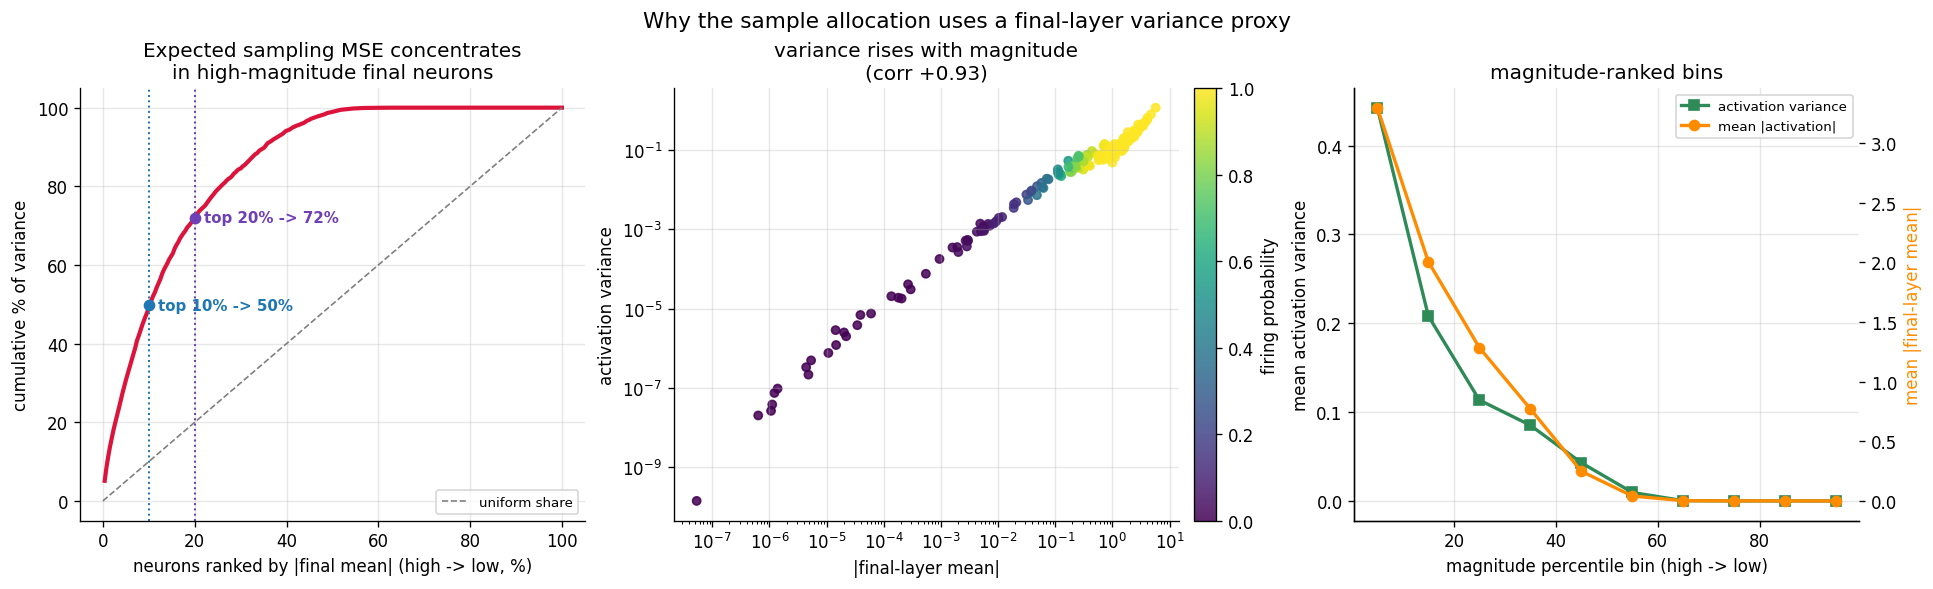

In [3]:
sample_stats = run_forward('ReLU', 50_000, seed=7, keep_posts=True)
final_activations = sample_stats['posts'][-1].astype(np.float64)
final_mean = final_activations.mean(axis=0)
final_var = final_activations.var(axis=0)
mag = np.abs(final_mean)
expected_sampling_mse = final_var  # common 1/N factor omitted; ranking/share is unchanged.
order = np.argsort(mag)[::-1]
rank_pct = 100.0 * (np.arange(WIDTH) + 1) / WIDTH
cum_mse = 100.0 * np.cumsum(expected_sampling_mse[order]) / expected_sampling_mse.sum()

deciles = np.linspace(0, 100, 11)
bin_centers, bin_var, bin_mag = [], [], []
for lo, hi in zip(deciles[:-1], deciles[1:]):
    start = int(np.floor(lo / 100 * WIDTH))
    stop = max(start + 1, int(np.floor(hi / 100 * WIDTH)))
    idx = order[start:stop]
    bin_centers.append((lo + hi) / 2)
    bin_var.append(float(np.mean(final_var[idx])))
    bin_mag.append(float(np.mean(mag[idx])))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
axes[0].plot(rank_pct, cum_mse, color='crimson', lw=2.5)
axes[0].plot([0, 100], [0, 100], color='gray', ls='--', lw=1, label='uniform share')
for cutoff, color in [(10, '#1f77b4'), (20, '#6f3fb5')]:
    k = max(1, int(round(WIDTH * cutoff / 100))) - 1
    axes[0].axvline(cutoff, color=color, ls=':', lw=1.2)
    axes[0].scatter([cutoff], [cum_mse[k]], color=color, zorder=3)
    axes[0].text(cutoff + 2, cum_mse[k], f'top {cutoff}% -> {cum_mse[k]:.0f}%', color=color, va='center', fontsize=9, fontweight='bold')
axes[0].set(title='Expected sampling MSE concentrates\nin high-magnitude final neurons',
            xlabel='neurons ranked by |final mean| (high -> low, %)', ylabel='cumulative % of variance')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(mag, final_var, c=sample_stats['firing_rates'][-1], s=24, cmap='viridis', alpha=0.85)
axes[1].set(xscale='log', yscale='log', title=f'variance rises with magnitude\n(corr {np.corrcoef(np.log1p(mag), np.log1p(final_var))[0, 1]:+.2f})',
            xlabel='|final-layer mean|', ylabel='activation variance')
axes[1].grid(alpha=0.3)
fig.colorbar(sc, ax=axes[1], label='firing probability', fraction=0.05, pad=0.02)

axes[2].plot(bin_centers, bin_var, 's-', color='seagreen', lw=2, label='activation variance')
axes2 = axes[2].twinx()
axes2.plot(bin_centers, bin_mag, 'o-', color='darkorange', lw=2, label='mean |activation|')
axes[2].set(title='magnitude-ranked bins', xlabel='magnitude percentile bin (high -> low)', ylabel='mean activation variance')
axes2.set_ylabel('mean |final-layer mean|', color='darkorange')
axes[2].grid(alpha=0.3)
lines, labels = axes[2].get_legend_handles_labels()
lines2, labels2 = axes2.get_legend_handles_labels()
axes[2].legend(lines + lines2, labels + labels2, fontsize=8, loc='upper right')

fig.suptitle('Why the sample allocation uses a final-layer variance proxy', fontsize=13)
out = FIG_DIR / 'final_magnitude_sampling_difficulty.png'
fig.savefig(out, dpi=220, bbox_inches='tight')
print(f'wrote {out} ({out.stat().st_size:,} bytes)')
plt.show()

## Figure 2: ReLU Activation Design Matrix

In [ ]:
vis_layers = [0, 7, 15, 23, 31]
vis_stats = run_forward('ReLU', 2048, seed=42, keep_posts=True)
row_idx = np.linspace(0, 2048 - 1, 512).astype(int)
fig, axes = plt.subplots(len(vis_layers), 1, figsize=(13.5, 9.2), sharex=True)
for ax, layer_index in zip(axes, vis_layers):
    rates = relu_stats['firing_rates'][layer_index]
    dead = off[layer_index]
    dense = (rates >= 0.5) & ~dead
    sparse = ~dead & ~dense
    cls = np.zeros(WIDTH, dtype=int)
    cls[sparse] = 1
    cls[dense] = 2
    order = np.argsort(rates, kind='stable')
    activations = vis_stats['posts'][layer_index][row_idx][:, order]
    cls_sorted = cls[order]
    rates_sorted = rates[order]
    scale = np.percentile(activations[activations > 0], 99) if np.any(activations > 0) else 1.0
    intensity = np.clip(activations / max(scale, 1e-12), 0, 1) ** 0.55
    img = np.ones((row_idx.size, WIDTH, 3), dtype=float)
    for col in range(WIDTH):
        if cls_sorted[col] == 0:
            img[:, col, :] = np.array([1.0, 0.88, 0.88])
        else:
            img[:, col, :] = 1.0 - intensity[:, col, None] * (1.0 - class_rgb[cls_sorted[col]])
    ax.imshow(img, aspect='auto', interpolation='nearest')
    for boundary in np.where(np.diff(cls_sorted) != 0)[0] + 0.5:
        ax.axvline(boundary, color='black', lw=0.7, alpha=0.55)
    ribbon_ax = ax.inset_axes([0, 1.02, 1, 0.10])
    ribbon_ax.imshow(class_rgb[cls_sorted][None, :, :], aspect='auto', interpolation='nearest')
    ribbon_ax.set_xticks([]); ribbon_ax.set_yticks([])
    for spine in ribbon_ax.spines.values():
        spine.set_visible(False)
    counts = [int((cls_sorted == k).sum()) for k in range(3)]
    ax.set_ylabel(f'L{layer_index + 1}\nsamples')
    ax.set_yticks([])
    ax.text(1.005, 0.5, f'dead {counts[0]}\nsparse {counts[1]}\ndense {counts[2]}',
            transform=ax.transAxes, ha='left', va='center', fontsize=8, color='0.25')
    ax.set_title(f'layer {layer_index + 1}: columns sorted by firing rate '
                 f'(min={rates_sorted[0]:.2f}, median={np.median(rates_sorted):.2f}, max={rates_sorted[-1]:.2f})',
                 fontsize=9, loc='left')
axes[-1].set_xlabel('neuron columns sorted by firing rate (0 -> 1)')
fig.legend(handles=[Patch(facecolor=colors['dead'], label='always-off / dead'),
                    Patch(facecolor=colors['sparse'], label='sparse block: 0 < fire < 0.5'),
                    Patch(facecolor=colors['dense'], label='dense block: fire >= 0.5')],
           loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Sample activation design matrices reveal the dense/sparse routing structure\n'
             'colored entries are positive post-ReLU activations; top ribbons show the column routing class',
             fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0.04, 0.90, 0.98])
fig.savefig(FIG_DIR / 'layer_collapse_activation_design_matrix.png', dpi=220, bbox_inches='tight')
plt.show()

## Figure 3: ReLU Covariance Block Waterfall

In [ ]:
cov_layers = [0, 1, 3, 7, 15, 23, 31]
relu_cov_stats = run_forward('ReLU', 8192, seed=123, keep_posts=True)
cov_records = []
for layer_index in cov_layers:
    cov = covariance_matrix(relu_cov_stats['posts'][layer_index])
    order, counts, edges = covariance_blocks(cov)
    cov_records.append((layer_index, cov[np.ix_(order, order)], counts, edges))
global_v = max(np.percentile(np.abs(rec[1]), 99.5) for rec in cov_records)
fig = plt.figure(figsize=(18, 3.4), constrained_layout=True)
gs = fig.add_gridspec(1, len(cov_records) + 1, width_ratios=[1] * len(cov_records) + [0.035])
last_im = None
for i, (layer_index, matrix, counts, edges) in enumerate(cov_records):
    ax = fig.add_subplot(gs[0, i])
    last_im = ax.imshow(matrix, cmap='RdBu_r', vmin=-global_v, vmax=global_v, interpolation='nearest')
    for edge in edges:
        ax.axhline(edge - 0.5, color='black', lw=0.55)
        ax.axvline(edge - 0.5, color='black', lw=0.55)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'L{layer_index + 1}\nsparse={counts[2]}, dense={counts[3]}', fontsize=8.5)
cax = fig.add_subplot(gs[0, -1])
fig.colorbar(last_im, cax=cax, label='covariance')
fig.suptitle('ReLU covariance reordered by dead/near-identity/sparse/dense blocks\n'
             'matched random MLP; shared color scale and dedicated colorbar axis', fontsize=12)
fig.savefig(FIG_DIR / 'relu_covariance_block_waterfall.png', dpi=220, bbox_inches='tight')
plt.show()

## Figure 4: Activation-Function Regime Comparison

In [ ]:
activation_names = ['ReLU', 'GELU', 'SiLU']
analysis = {name: run_forward(name, 20_000, seed=42, keep_posts=True) for name in activation_names}
regime_counts = {}
for name in activation_names:
    if name == 'ReLU':
        lo, mid, hi = relu_regimes(analysis[name])
    else:
        lo, mid, hi = smooth_regimes(name)
    regime_counts[name] = (lo.sum(axis=1), mid.sum(axis=1), hi.sum(axis=1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.7), sharey=True)
for ax, name in zip(axes, activation_names):
    lo, mid, hi = regime_counts[name]
    labels = ['always-off / dead', 'near-kink', 'always-on / linear'] if name == 'ReLU' else ['near-zero scale', 'smooth transition', 'near-linear']
    ax.stackplot(np.arange(DEPTH), lo, mid, hi, labels=labels, colors=['crimson', 'darkorange', 'seagreen'], alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel('layer index')
    ax.set_ylim(0, WIDTH)
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel('# neurons')
axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('Matched random MLPs under ReLU-He scaling: ReLU has hard regimes; smooth activations mostly change scale', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(FIG_DIR / 'activation_function_regime_comparison.png', dpi=220, bbox_inches='tight')
plt.show()

## Figure 5: Activation-Function Design Matrix Comparison

In [ ]:
fig, axes = plt.subplots(len(activation_names), len(vis_layers), figsize=(16, 8.8), sharex=True, sharey=True)
for row, name in enumerate(activation_names):
    stats = analysis[name]
    low_masks = relu_regimes(stats)[0] if name == 'ReLU' else smooth_regimes(name)[0]
    for col, layer_index in enumerate(vis_layers):
        ax = axes[row, col]
        rates = stats['firing_rates'][layer_index]
        low_mask = low_masks[layer_index]
        dense = (rates >= 0.5) & ~low_mask
        sparse = ~low_mask & ~dense
        cls = np.zeros(WIDTH, dtype=int)
        cls[sparse] = 1
        cls[dense] = 2
        order = np.argsort(rates, kind='stable')
        activations = stats['posts'][layer_index][row_idx][:, order]
        cls_sorted = cls[order]
        scale = np.percentile(np.abs(activations), 99) if np.any(activations) else 1.0
        intensity = np.clip(np.abs(activations) / max(scale, 1e-12), 0, 1) ** 0.55
        img = np.ones((row_idx.size, WIDTH, 3), dtype=float)
        for c in range(WIDTH):
            if cls_sorted[c] == 0:
                img[:, c, :] = np.array([1.0, 0.88, 0.88])
            else:
                img[:, c, :] = 1.0 - intensity[:, c, None] * (1.0 - class_rgb[cls_sorted[c]])
        ax.imshow(img, aspect='auto', interpolation='nearest')
        for boundary in np.where(np.diff(cls_sorted) != 0)[0] + 0.5:
            ax.axvline(boundary, color='black', lw=0.45, alpha=0.45)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f'L{layer_index + 1}', fontsize=10)
        if col == 0:
            ax.set_ylabel(name, rotation=0, labelpad=32, va='center', fontsize=11)
        counts = [int((cls_sorted == k).sum()) for k in range(3)]
        ax.text(0.02, 0.08, f'{counts[0]}/{counts[1]}/{counts[2]}', transform=ax.transAxes,
                fontsize=7, color='black', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5))
fig.legend(handles=[Patch(facecolor=colors['dead'], label='dead or near-zero scale'),
                    Patch(facecolor=colors['sparse'], label='transition: 0 < fire < 0.5'),
                    Patch(facecolor=colors['dense'], label='high-fire: fire >= 0.5')],
           loc='lower center', ncol=3, frameon=False)
fig.suptitle('Sorted sample activation matrices under matched weights and activation functions\n'
             'columns ordered by firing rate; cell intensity is |activation|', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 0.93])
fig.savefig(FIG_DIR / 'activation_function_design_matrix_comparison.png', dpi=220, bbox_inches='tight')
plt.show()

## Figure 6: Activation-Function Covariance Comparison

In [ ]:
comparison_layers = [0, 7, 15, 23, 31]
cov_data = {}
for name in activation_names:
    stats = run_forward(name, 8192, seed=123, keep_posts=True)
    snaps = {}
    for layer_index in comparison_layers:
        cov = covariance_matrix(stats['posts'][layer_index])
        corr = np.abs(corr_from_cov(cov))
        rates = stats['firing_rates'][layer_index]
        order = np.argsort(rates, kind='stable')
        live = np.diag(cov) > 1e-12
        if live.sum() > 1:
            abs_corr = corr[np.ix_(live, live)]
            mean_abs_corr = float((abs_corr.sum() - live.sum()) / (live.sum() * (live.sum() - 1)))
        else:
            mean_abs_corr = 0.0
        snaps[layer_index] = {
            'matrix': corr[np.ix_(order, order)],
            'rates': rates[order],
            'eff_rank': effective_rank(cov),
            'mean_abs_corr': mean_abs_corr,
            'diagvar': float(np.diag(cov).mean()),
        }
    cov_data[name] = snaps

fig = plt.figure(figsize=(16.8, 8.8), constrained_layout=True)
gs = fig.add_gridspec(len(activation_names), len(comparison_layers) + 1, width_ratios=[1] * len(comparison_layers) + [0.035])
last_im = None
for row, name in enumerate(activation_names):
    for col, layer_index in enumerate(comparison_layers):
        ax = fig.add_subplot(gs[row, col])
        snap = cov_data[name][layer_index]
        last_im = ax.imshow(snap['matrix'], cmap='magma', vmin=0, vmax=1, interpolation='nearest')
        boundary = np.searchsorted(snap['rates'], 0.5)
        if 0 < boundary < WIDTH:
            ax.axhline(boundary - 0.5, color='cyan', lw=0.7, alpha=0.75)
            ax.axvline(boundary - 0.5, color='cyan', lw=0.7, alpha=0.75)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f'L{layer_index + 1}', fontsize=10)
        if col == 0:
            ax.set_ylabel(name, rotation=0, labelpad=32, va='center', fontsize=11)
        ax.text(0.02, 0.04, f"rank {snap['eff_rank']:.1f}\n|corr| {snap['mean_abs_corr']:.2f}\nvar {snap['diagvar']:.1e}",
                transform=ax.transAxes, fontsize=6.5, color='white',
                bbox=dict(facecolor='black', alpha=0.45, edgecolor='none', pad=1.5))
cax = fig.add_subplot(gs[:, -1])
fig.colorbar(last_im, cax=cax, label='absolute correlation')
fig.suptitle('Activation covariance/rank-collapse comparison under matched ReLU-He random weights\n'
             'matrices sorted by firing rate; cyan line marks fire-rate 0.5 boundary', fontsize=13)
fig.savefig(FIG_DIR / 'activation_function_covariance_comparison.png', dpi=220, bbox_inches='tight')
plt.show()